# Sweden TV Series Success Analysis — Python Project

## Business scenario

Our group works for a major Swedish TV broadcaster. The executives want to understand:

**Q1. What makes a Swedish TV series successful?**  
**Q2. What types of television shows should we invest in the future?**

This notebook uses a historical IMDb TV dataset to prepare a simple business analysis using 

- pandas
- numpy
- matplotlib

## How success is measured in this analysis

A TV show is considered successful when it has:

1. A good IMDb rating
2. A strong number of audience votes
3. A reasonable runtime pattern
4. Clear year and content rating information
5. Award recognition, if available

Because rating alone can be misleading, this notebook uses both **rating** and **votes** to understand success.

## Step 1 — Import libraries

I use only basic Python libraries for this project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 — Set the data folder

In [3]:
DATA_FOLDER = r"C:\Hyper_Island\IMDb_data\tableau final assignment"
print("Data folder:", DATA_FOLDER)

Data folder: C:\Hyper_Island\IMDb_data\tableau final assignment


## Step 3 — Load the important dataset tables

For this business question, we mainly need:

- `fact_Title` for Swedish title-level analysis
- `dim_Series` for series-level analysis
- `fact_TitleRatings` for Sweden title age ratings
- `fact_SeriesRating` for Sweden series age ratings
- award and genre tables for supporting analysis

In [4]:
fact_Title = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_fact_Title.csv", low_memory=False)
dim_Series = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_dim_Series.csv", low_memory=False)
fact_TitleRatings = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_fact_TitleRating.csv", low_memory=False)
fact_SeriesRating = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_fact_SeriesRating.csv", low_memory=False)
fact_TitleAward = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_fact_TitleAwardNominations.csv", low_memory=False)
fact_SeriesAward = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_fact_SeriesAwardNominations.csv", low_memory=False)
dim_TitleGenre = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_dim_TitleGenre.csv", low_memory=False)
dim_SeriesGenre = pd.read_csv(DATA_FOLDER + "\Data+TV IMDb Dataset_dim_SeriesGenre.csv", low_memory=False)

print("Files loaded successfully")

Files loaded successfully


## Step 4 — Check the size of each table

This helps us understand how much data we have before analysis.

In [5]:
table_summary = pd.DataFrame({
    "Table Name": [
        "fact_Title", "dim_Series", "fact_TitleRatings", "fact_SeriesRating",
        "fact_TitleAward", "fact_SeriesAward", "dim_TitleGenre", "dim_SeriesGenre"
    ],
    "Rows": [
        fact_Title.shape[0], dim_Series.shape[0], fact_TitleRatings.shape[0], fact_SeriesRating.shape[0],
        fact_TitleAward.shape[0], fact_SeriesAward.shape[0], dim_TitleGenre.shape[0], dim_SeriesGenre.shape[0]
    ],
    "Columns": [
        fact_Title.shape[1], dim_Series.shape[1], fact_TitleRatings.shape[1], fact_SeriesRating.shape[1],
        fact_TitleAward.shape[1], fact_SeriesAward.shape[1], dim_TitleGenre.shape[1], dim_SeriesGenre.shape[1]
    ]
})

table_summary

,Table Name,Rows,Columns
0,fact_Title,4829,16
1,dim_Series,199468,11
2,fact_TitleRatings,1379699,7
3,fact_SeriesRating,31515,7
4,fact_TitleAward,3770,1
5,fact_SeriesAward,180655,1
6,dim_TitleGenre,28,1
7,dim_SeriesGenre,28,1


## Step 5 — Check column names

Before cleaning, I check the column names so we know what is available.

In [6]:
print("fact_Title columns:")
print(fact_Title.columns.tolist())

print("dim_Series columns:")
print(dim_Series.columns.tolist())

print("fact_TitleRatings columns:")
print(fact_TitleRatings.columns.tolist())

print("fact_SeriesRating columns:")
print(fact_SeriesRating.columns.tolist())

fact_Title columns:
['Country Code', 'Episode Number', 'IMDb Title ID', 'IMDb Title Image URL', 'IMDb Title URL', 'PK.TitleID', 'PK.TitleID (bin)', 'Release Year', 'ReleaseDate ( MM / YYYY )', 'Runtime (Minutes) (bin)', 'Season Number', 'Title', 'Title Plot Synopsis', 'IMDb Title Number Of Votes', 'IMDb Title Rating', 'Runtime (Minutes)']
dim_Series columns:
['IMDb Series ID', 'IMDb Series Image URL', 'IMDb Series URL', 'PK.SeriesID', 'Series End Year', 'Series Plot Synopsis', 'Series Start Year', 'Series Title', 'Series Type', 'IMDb Series Number Of Votes', 'IMDb Series Rating']
fact_TitleRatings columns:
['Australia Rating (Title)', 'Brazil Rating (Title)', 'Germany Rating (Title)', 'Great Britain Rating (Title)', 'India Rating (Title)', 'Sweden Rating (Title)', 'US Rating (Title)']
fact_SeriesRating columns:
['Australia Rating (Series)', 'Brazil Rating (Series)', 'Germany Rating (Series)', 'Great Britain Rating (Series)', 'India Rating (Series)', 'Sweden Rating (Series)', 'US Rating

## Step 6 — Clean important numeric columns

Some numeric columns may be stored as text.  
I convert them into numbers so I can calculate averages and create charts.

In [7]:
# Clean title columns
fact_Title["IMDb Title Rating"] = fact_Title["IMDb Title Rating"].astype(str).str.replace(",", ".")
fact_Title["IMDb Title Rating"] = pd.to_numeric(fact_Title["IMDb Title Rating"], errors="coerce")

fact_Title["IMDb Title Number Of Votes"] = fact_Title["IMDb Title Number Of Votes"].astype(str).str.replace(",", ".")
fact_Title["IMDb Title Number Of Votes"] = pd.to_numeric(fact_Title["IMDb Title Number Of Votes"], errors="coerce")

fact_Title["Runtime (Minutes)"] = fact_Title["Runtime (Minutes)"].astype(str).str.replace(",", ".")
fact_Title["Runtime (Minutes)"] = pd.to_numeric(fact_Title["Runtime (Minutes)"], errors="coerce")

fact_Title["Release Year"] = pd.to_numeric(fact_Title["Release Year"], errors="coerce")

print("fact_Title numeric columns cleaned")

fact_Title numeric columns cleaned


In [25]:
# Clean series columns
if "IMDb Series Rating" in dim_Series.columns:
    dim_Series["IMDb Series Rating"] = dim_Series["IMDb Series Rating"].astype(str).str.replace(",", ".")
    dim_Series["IMDb Series Rating"] = pd.to_numeric(dim_Series["IMDb Series Rating"], errors="coerce")

if "IMDb Series Number Of Votes" in dim_Series.columns:
    dim_Series["IMDb Series Number Of Votes"] = dim_Series["IMDb Series Number Of Votes"].astype(str).str.replace(",", ".")
    dim_Series["IMDb Series Number Of Votes"] = pd.to_numeric(dim_Series["IMDb Series Number Of Votes"], errors="coerce")

if "Series Start Year" in dim_Series.columns:
    dim_Series["Series Start Year"] = pd.to_numeric(dim_Series["Series Start Year"], errors="coerce")

if "Series End Year" in dim_Series.columns:
    dim_Series["Series End Year"] = pd.to_numeric(dim_Series["Series End Year"], errors="coerce")

print("dim_Series numeric columns cleaned")

dim_Series numeric columns cleaned


## Step 7 — Filter Sweden data

The `fact_Title` table has a `Country Code` column.  
For Sweden, the country code is usually `SE`.

In [9]:
print("Country code counts:")
print(fact_Title["Country Code"].value_counts(dropna=False).head(20))

Country code counts:
Country Code
SE    4829
Name: count, dtype: int64


In [10]:
sweden_titles = fact_Title[fact_Title["Country Code"] == "SE"].copy()

print("Total records in fact_Title:", fact_Title.shape[0])
print("Sweden records:", sweden_titles.shape[0])

sweden_titles.head()

Total records in fact_Title: 4829
Sweden records: 4829


,Country Code,Episode Number,IMDb Title ID,IMDb Title Image URL,IMDb Title URL,PK.TitleID,PK.TitleID (bin),Release Year,ReleaseDate ( MM / YYYY ),Runtime (Minutes) (bin),Season Number,Title,Title Plot Synopsis,IMDb Title Number Of Votes,IMDb Title Rating,Runtime (Minutes)
0,SE,3.0,tt1706769,https://m.media-amazon.com/images/M/MV5BMThkNG...,http://www.imdb.com/title/tt1706769,3058146,3037K,1980.0,1980-04-01,20.0,1.0,En kommissarie börjar undra,Months after the bank robbery Bertilsson recei...,5.0,6.4,29.0
1,SE,1.0,tt1706772,https://m.media-amazon.com/images/M/MV5BNWVmZT...,http://www.imdb.com/title/tt1706772,3058164,3037K,1980.0,1980-03-01,30.0,1.0,Två gamla skolkamrater träffas,A doctor and a school principal hatch a plan t...,5.0,6.4,30.0
2,SE,2.0,tt1706774,https://m.media-amazon.com/images/M/MV5BNzU2ZG...,http://www.imdb.com/title/tt1706774,3058176,3037K,1980.0,1980-03-01,20.0,1.0,Välfärd föder brott,Doctor Stensson and principal Bertilsson rob t...,5.0,6.6,28.0
3,SE,5.0,tt1706773,https://m.media-amazon.com/images/M/MV5BNzZiYW...,http://www.imdb.com/title/tt1706773,3058170,3037K,1980.0,1980-04-01,20.0,1.0,Vem vet vad om vem?,"With the police investigation going nowhere, t...",5.0,6.6,28.0
4,SE,6.0,tt1706771,https://m.media-amazon.com/images/M/MV5BMjE3NG...,http://www.imdb.com/title/tt1706771,3058158,3037K,1980.0,1980-05-01,20.0,1.0,Konsten att ta Nobelpriset,"The doctor and the principal steal 5,000,000 S...",6.0,6.7,29.0


In [11]:
# Remove rows where release year or votes are missing for display
sweden_titles["Release Year"] = sweden_titles["Release Year"].astype("Int64")
sweden_titles["IMDb Title Number Of Votes"] = sweden_titles["IMDb Title Number Of Votes"].astype("Int64")

## Step 8 — Data Quality Check for Swedish Titles

Before answering the business questions, I checked the quality of the Swedish title data. This step helps identify missing values in important columns such as release year, IMDb rating, number of votes, and runtime.

This is important because business decisions should not be made without understanding how complete and reliable the data is. If key values are missing, the analysis may not fully represent the performance of Swedish TV titles.


In [12]:
missing_values = sweden_titles.isna().sum()
missing_percent = sweden_titles.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percent": missing_percent.round(2)
})

missing_summary.sort_values("Missing Percent", ascending=False).head(20)

,Missing Values,Missing Percent
IMDb Title Number Of Votes,3091,64.01
IMDb Title Rating,3091,64.01
IMDb Title Image URL,2933,60.74
Title Plot Synopsis,2444,50.61
Runtime (Minutes) (bin),1292,26.76
Runtime (Minutes),1292,26.76
ReleaseDate ( MM / YYYY ),248,5.14
Episode Number,20,0.41
Season Number,20,0.41
Release Year,15,0.31


## Step 9 — Create clean datasets for analysis

We do not drop all missing values from the full dataset.  
Instead, we create small clean datasets for each analysis.

In [13]:
titles_with_rating = sweden_titles.dropna(subset=["IMDb Title Rating", "IMDb Title Number Of Votes"]).copy()
titles_with_runtime = sweden_titles.dropna(subset=["Runtime (Minutes)"]).copy()
titles_with_year = sweden_titles.dropna(subset=["Release Year"]).copy()

print("Sweden title records:", sweden_titles.shape[0])
print("With rating and votes:", titles_with_rating.shape[0])
print("With runtime:", titles_with_runtime.shape[0])
print("With release year:", titles_with_year.shape[0])

Sweden title records: 4829
With rating and votes: 1738
With runtime: 3537
With release year: 4814


# Business Question 1 — What makes a Swedish TV series successful?

We answer this by studying:

- IMDb rating
- number of audience votes
- rating and votes together
- runtime
- release trend
- Sweden age rating

## Step 10 — KPI summary

These KPIs give a quick executive overview.

In [14]:
total_titles = sweden_titles.shape[0]
avg_rating = titles_with_rating["IMDb Title Rating"].mean()
total_votes = titles_with_rating["IMDb Title Number Of Votes"].sum()
avg_runtime = titles_with_runtime["Runtime (Minutes)"].mean()

print("Total Swedish title records:", total_titles)
print("Average IMDb rating:", round(avg_rating, 2))
print("Total audience votes:", int(total_votes))
print("Average runtime:", round(avg_runtime, 1), "minutes")

Total Swedish title records: 4829
Average IMDb rating: 6.91
Total audience votes: 180683
Average runtime: 36.4 minutes


## Step 11 — Swedish TV title production trend by year

This shows when more Swedish TV content appeared in the dataset.

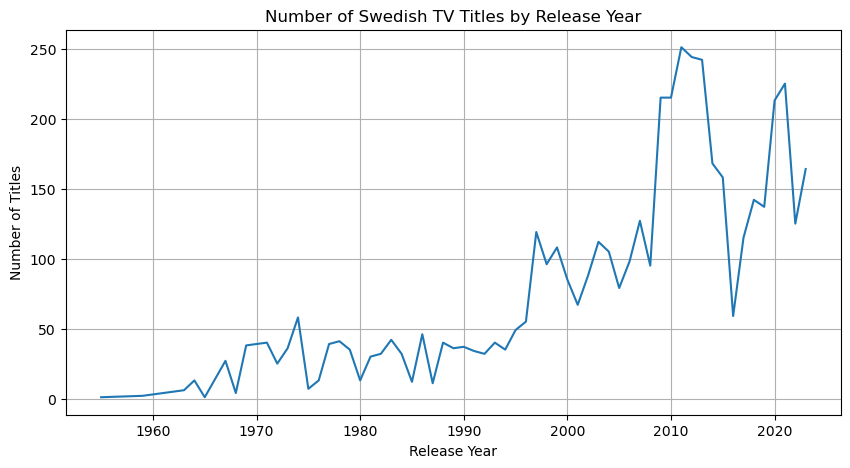

In [15]:
titles_by_year = titles_with_year.groupby("Release Year").size()

plt.figure(figsize=(10,5))
plt.plot(titles_by_year.index, titles_by_year.values)
plt.title("Number of Swedish TV Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

In [16]:
top_years = titles_by_year.sort_values(ascending=False).head(10)
top_years

Release Year
2011    251
2012    244
2013    242
2021    225
2010    215
2009    215
2020    213
2014    168
2023    164
2015    158
dtype: int64

## Step 12 — IMDb rating distribution

This helps us understand whether most Swedish shows are low-rated, average, or highly rated.

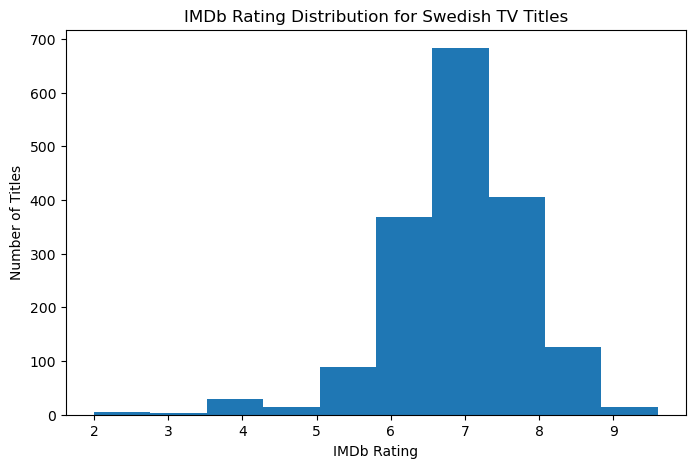

In [17]:
plt.figure(figsize=(8,5))
plt.hist(titles_with_rating["IMDb Title Rating"], bins=10)
plt.title("IMDb Rating Distribution for Swedish TV Titles")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Titles")
plt.show()

In [18]:
print("Average rating:", round(titles_with_rating["IMDb Title Rating"].mean(), 2))
print("Median rating:", round(titles_with_rating["IMDb Title Rating"].median(), 2))
print("Highest rating:", titles_with_rating["IMDb Title Rating"].max())
print("Lowest rating:", titles_with_rating["IMDb Title Rating"].min())

Average rating: 6.91
Median rating: 7.0
Highest rating: 9.6
Lowest rating: 2.0


## Step 13 — Audience engagement using votes

Votes show audience engagement.  
A show with many votes has stronger audience visibility than a show with only a few votes.

In [19]:
top_rated = titles_with_rating.sort_values(
    "IMDb Title Rating",
    ascending=False
).head(10)

top_rated[["Title", "Release Year", "IMDb Title Rating", "IMDb Title Number Of Votes"]]

,Title,Release Year,IMDb Title Rating,IMDb Title Number Of Votes
3417,O,1977,9.6,8
2947,Äventyret Börjar,2023,9.4,21
3697,Släktingen,2020,9.2,5
2313,Avsnitt 6,2022,9.2,1029
3688,Förälskelsen,2021,9.2,7
2568,Avsnitt 6,2021,9.2,2124
3687,Familjemiddag,2021,9.0,6
1997,Demonerna,1983,9.0,227
2567,Avsnitt 5,2021,9.0,1995
174,Episode #1.1,2012,8.9,12


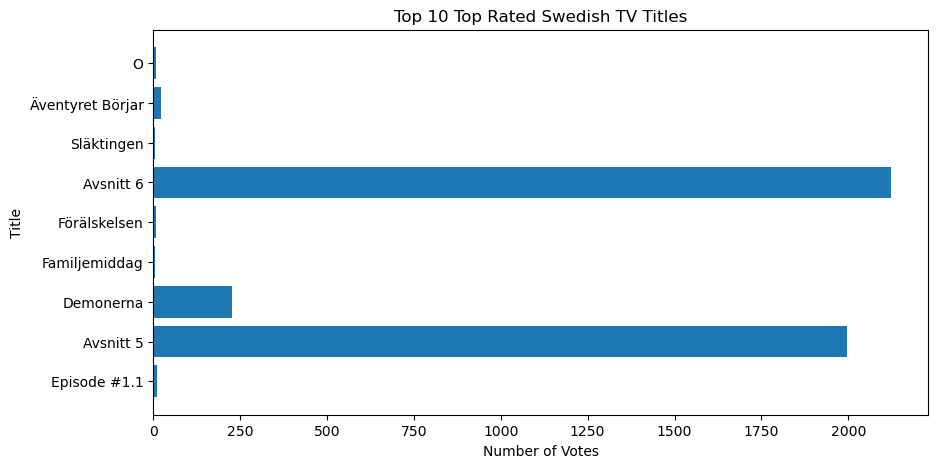

In [22]:
plt.figure(figsize=(10,5))
plt.barh(top_rated["Title"], top_rated["IMDb Title Number Of Votes"])
plt.title("Top 10 Top Rated Swedish TV Titles")
plt.xlabel("Number of Votes")
plt.ylabel("Title")
plt.gca().invert_yaxis()
plt.show()

## Step 14 — Rating vs votes

This is one of the most important charts for Q1.

It helps us see which shows have both:

- high rating
- high number of votes

Those shows are stronger examples of success.

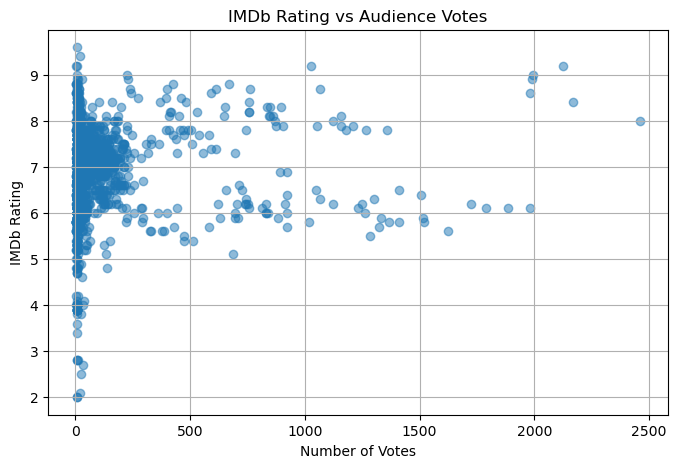

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(
    titles_with_rating["IMDb Title Number Of Votes"],
    titles_with_rating["IMDb Title Rating"],
    alpha=0.5
)
plt.title("IMDb Rating vs Audience Votes")
plt.xlabel("Number of Votes")
plt.ylabel("IMDb Rating")
plt.grid(True)
plt.show()

## Step 15 — Define successful Swedish TV titles

For this beginner-level project, we use a simple success rule:

A title is successful if:

- IMDb rating is **7.0 or higher**
- number of votes is **greater than or equal to the median votes**

This avoids choosing titles that have a high rating but very few votes.

In [67]:
median_votes = titles_with_rating["IMDb Title Number Of Votes"].median()

successful_titles = titles_with_rating[
    (titles_with_rating["IMDb Title Rating"] >= 7.0) &
    (titles_with_rating["IMDb Title Number Of Votes"] >= median_votes)
].copy()

print("Median votes:", median_votes)
print("Successful Swedish titles:", successful_titles.shape[0])

successful_titles[["Title", "Release Year", "IMDb Title Rating", "IMDb Title Number Of Votes"]].head(10)

Median votes: 21.0
Successful Swedish titles: 527


,Title,Release Year,IMDb Title Rating,IMDb Title Number Of Votes
54,"Godafton, vackra mask",2011,7.1,40
56,Avsnitt 2,2012,7.0,32
57,Avsnitt 5,2012,7.0,26
58,Avsnitt 6,2012,7.1,25
59,Avsnitt 8,2012,7.1,27
60,Avsnitt 9,2012,7.1,25
61,Avsnitt 3,2012,7.1,30
62,Avsnitt 10,2012,7.2,33
63,Avsnitt 1,2012,7.2,43
64,Avsnitt 7,2012,7.2,27


In [68]:
top_successful = successful_titles.sort_values(
    ["IMDb Title Rating", "IMDb Title Number Of Votes"],
    ascending=False
).head(10)

top_successful[["Title", "Release Year", "IMDb Title Rating", "IMDb Title Number Of Votes"]]

,Title,Release Year,IMDb Title Rating,IMDb Title Number Of Votes
2947,Äventyret Börjar,2023,9.4,21
2568,Avsnitt 6,2021,9.2,2124
2313,Avsnitt 6,2022,9.2,1029
2567,Avsnitt 5,2021,9.0,1995
1997,Demonerna,1983,9.0,227
2566,Avsnitt 4,2021,8.9,1988
1996,Sommarens händelser,1983,8.9,230
2329,Slutet/början,2023,8.9,28
4271,Kärringar mot strömmen,2013,8.8,672
3031,Paula,1973,8.8,428


## Step 16 — Runtime analysis

Runtime helps answer what format works better:

- short format
- medium format
- long format

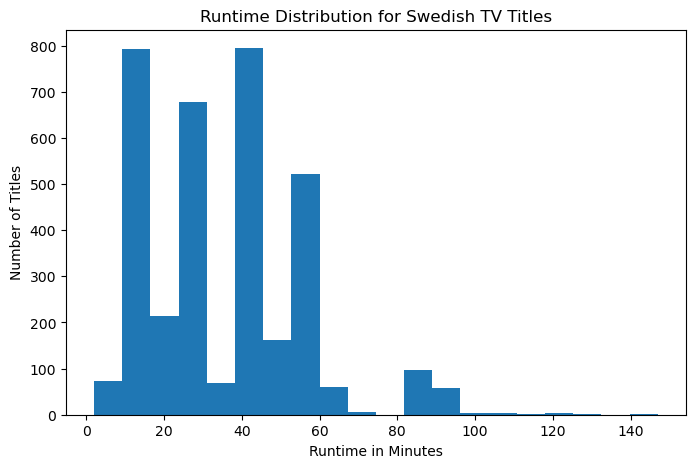

In [69]:
plt.figure(figsize=(8,5))
plt.hist(titles_with_runtime["Runtime (Minutes)"], bins=20)
plt.title("Runtime Distribution for Swedish TV Titles")
plt.xlabel("Runtime in Minutes")
plt.ylabel("Number of Titles")
plt.show()

In [70]:
# Create simple runtime categories

titles_with_runtime["Runtime Category"] = "Medium"
titles_with_runtime.loc[titles_with_runtime["Runtime (Minutes)"] < 30, "Runtime Category"] = "Short"
titles_with_runtime.loc[titles_with_runtime["Runtime (Minutes)"] >= 60, "Runtime Category"] = "Long"

runtime_counts = titles_with_runtime["Runtime Category"].value_counts()
runtime_counts

Runtime Category
Medium    1744
Short     1558
Long       235
Name: count, dtype: int64

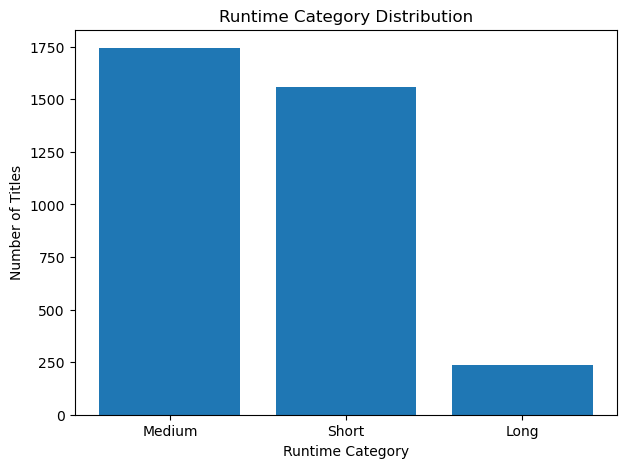

In [71]:
plt.figure(figsize=(7,5))
plt.bar(runtime_counts.index, runtime_counts.values)
plt.title("Runtime Category Distribution")
plt.xlabel("Runtime Category")
plt.ylabel("Number of Titles")
plt.show()

## Step 17 — Average rating by runtime category

This helps answer what content length may perform better.

In [72]:
runtime_rating_data = titles_with_rating.copy()
runtime_rating_data = runtime_rating_data.dropna(subset=["Runtime (Minutes)"])

runtime_rating_data["Runtime Category"] = "Medium"
runtime_rating_data.loc[runtime_rating_data["Runtime (Minutes)"] < 30, "Runtime Category"] = "Short"
runtime_rating_data.loc[runtime_rating_data["Runtime (Minutes)"] >= 60, "Runtime Category"] = "Long"

avg_rating_by_runtime = runtime_rating_data.groupby("Runtime Category")["IMDb Title Rating"].mean().sort_values(ascending=False)
avg_rating_by_runtime

Runtime Category
Medium    7.099501
Short     6.773941
Long      6.675342
Name: IMDb Title Rating, dtype: float64

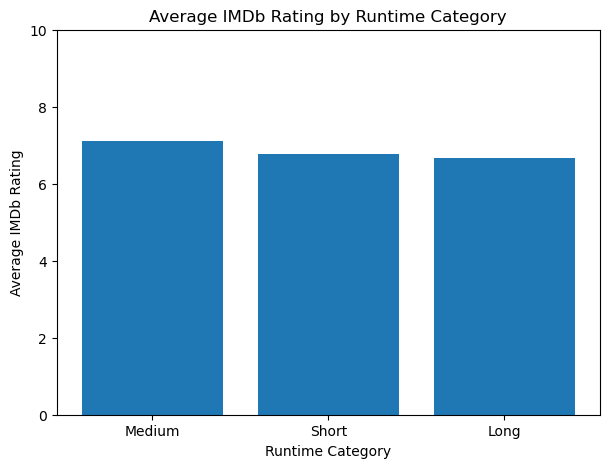

In [73]:
plt.figure(figsize=(7,5))
plt.bar(avg_rating_by_runtime.index, avg_rating_by_runtime.values)
plt.title("Average IMDb Rating by Runtime Category")
plt.xlabel("Runtime Category")
plt.ylabel("Average IMDb Rating")
plt.ylim(0, 10)
plt.show()

## Step 18 — Sweden age rating for titles

This shows which audience age categories are common in Swedish TV title data.

In [74]:
if "Sweden Rating (Title)" in fact_TitleRatings.columns:
    sweden_age_title = fact_TitleRatings["Sweden Rating (Title)"].value_counts(dropna=False)
    print(sweden_age_title.head(20))
else:
    print("Sweden Rating (Title) column not found")

Sweden Rating (Title)
NaN    1100872
Btl     212537
18+      50568
15       13734
11         461
16+        455
7+         311
12         262
18         209
7          148
13          66
10+         24
14          19
All         13
9            6
6            5
0+           4
9+           2
13+          1
IK           1
Name: count, dtype: int64


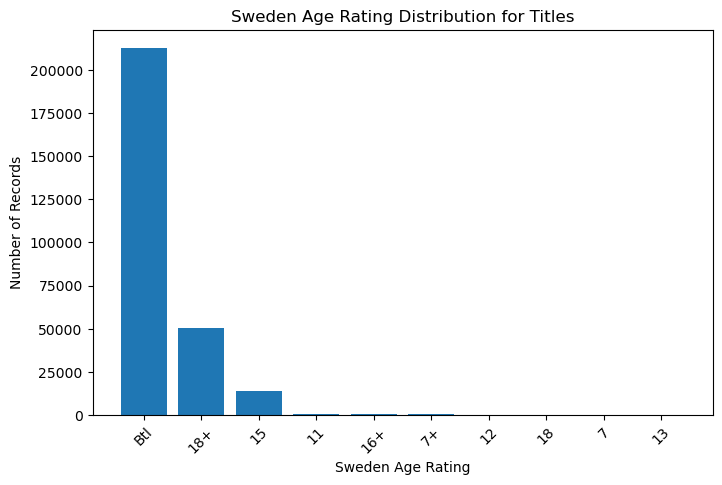

In [75]:
if "Sweden Rating (Title)" in fact_TitleRatings.columns:
    sweden_age_title_clean = fact_TitleRatings["Sweden Rating (Title)"].dropna().value_counts().head(10)
    
    plt.figure(figsize=(8,5))
    plt.bar(sweden_age_title_clean.index.astype(str), sweden_age_title_clean.values)
    plt.title("Sweden Age Rating Distribution for Titles")
    plt.xlabel("Sweden Age Rating")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.show()

## Step 19 — Sweden age rating for series

This supports future investment decisions by showing which age categories are common for series.

In [76]:
if "Sweden Rating (Series)" in fact_SeriesRating.columns:
    sweden_age_series = fact_SeriesRating["Sweden Rating (Series)"].value_counts(dropna=False)
    print(sweden_age_series.head(20))
else:
    print("Sweden Rating (Series) column not found")

Sweden Rating (Series)
NaN     28165
16+       849
15        699
13        408
Btl       318
7+        210
11        209
12        188
18+       104
7          71
All        67
6          32
18         28
0+         26
13+        25
Alla       19
10+        16
14         15
9          15
9+         14
Name: count, dtype: int64


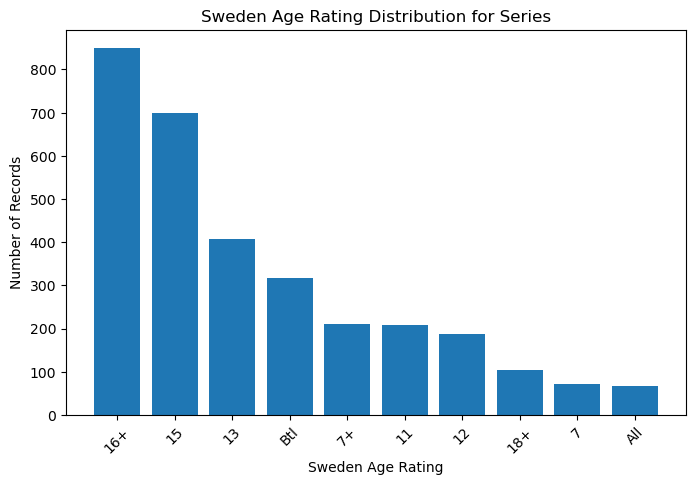

In [77]:
if "Sweden Rating (Series)" in fact_SeriesRating.columns:
    sweden_age_series_clean = fact_SeriesRating["Sweden Rating (Series)"].dropna().value_counts().head(10)
    
    plt.figure(figsize=(8,5))
    plt.bar(sweden_age_series_clean.index.astype(str), sweden_age_series_clean.values)
    plt.title("Sweden Age Rating Distribution for Series")
    plt.xlabel("Sweden Age Rating")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.show()

# Business Question 2 — What types of television shows should we invest in the future?

To answer this, we look at:

- high rating + high vote titles
- runtime category performance
- age rating categories
- yearly trends
- series-level performance
- award recognition

## Step 20 — Series-level analysis

The `dim_Series` table gives series-level information.  
If it does not contain country code, we should not claim it is Sweden-only.  
But it still helps understand TV series performance in the dataset.

In [26]:
series_with_rating = dim_Series.dropna(subset=["IMDb Series Rating", "IMDb Series Number Of Votes"]).copy()

print("Total series records:", dim_Series.shape[0])
print("Series with rating and votes:", series_with_rating.shape[0])

Total series records: 199468
Series with rating and votes: 100939


In [28]:
# Top reliable series using the same idea: rating and votes together
series_median_votes = series_with_rating["IMDb Series Number Of Votes"].median()

successful_series = series_with_rating[
    (series_with_rating["IMDb Series Rating"] >= 7.0) &
    (series_with_rating["IMDb Series Number Of Votes"] >= series_median_votes)
].copy()

print("Median series votes:", series_median_votes)
print("Successful series records:", successful_series.shape[0])

successful_series[["Series Title", "Series Start Year", "IMDb Series Rating", "IMDb Series Number Of Votes"]].head(10)

Median series votes: 41.0
Successful series records: 29116


,Series Title,Series Start Year,IMDb Series Rating,IMDb Series Number Of Votes
0,Queridos Amigos,2008.0,7.8,80.0
1,Inside the Medieval Mind,2008.0,7.8,147.0
3,Sunshine,2008.0,8.0,276.0
4,Inside the Vietnam War,2008.0,8.1,94.0
5,Tropic of Capricorn,2008.0,8.1,170.0
8,Wildes Russland,2008.0,8.2,673.0
10,Chuck Versus the Webisodes,2008.0,8.3,67.0
12,Sex: The Revolution,2008.0,8.4,273.0
13,Carrier,2008.0,8.4,640.0
14,The Genius of Charles Darwin,2008.0,8.4,1007.0


In [29]:
top_series = successful_series.sort_values(
    ["IMDb Series Rating", "IMDb Series Number Of Votes"],
    ascending=False
).head(10)

top_series[["Series Title", "Series Start Year", "IMDb Series Rating", "IMDb Series Number Of Votes"]]

,Series Title,Series Start Year,IMDb Series Rating,IMDb Series Number Of Votes
161988,Cumartesi & Pazar Sürprizi,2016.0,9.8,3846.0
161986,Friday Five Sharp,2015.0,9.7,4511.0
165244,Choufli Hal,2005.0,9.7,2921.0
127675,OdBita Pot,2022.0,9.7,847.0
138998,Nocna mora Zeljka Malnara,1992.0,9.7,245.0
179135,Steven Reeds Weber Cooks,2012.0,9.7,205.0
9500,K-15,1995.0,9.7,203.0
161987,Prime Time,2016.0,9.7,178.0
69114,Jogandofoddaci,2019.0,9.7,164.0
15994,Craft Games,2014.0,9.7,146.0


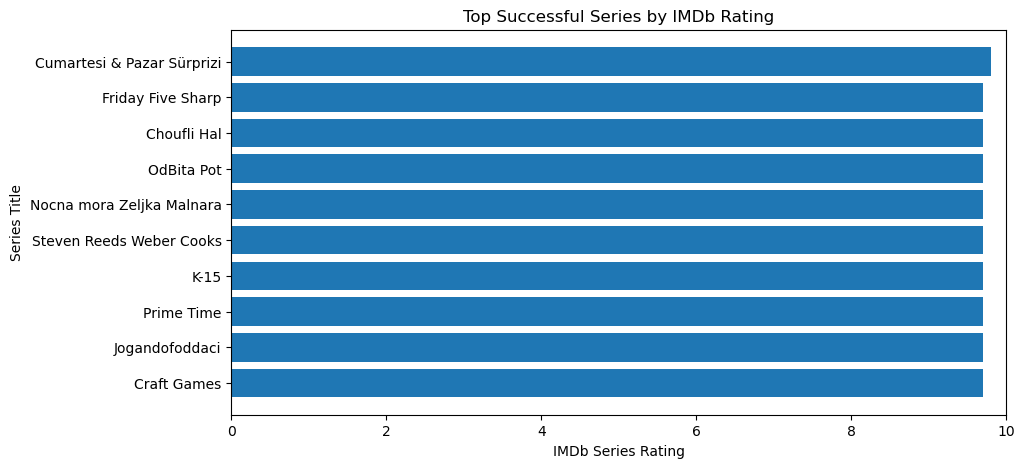

In [30]:
plt.figure(figsize=(10,5))
plt.barh(top_series["Series Title"], top_series["IMDb Series Rating"])
plt.title("Top Successful Series by IMDb Rating")
plt.xlabel("IMDb Series Rating")
plt.ylabel("Series Title")
plt.xlim(0, 10)
plt.gca().invert_yaxis()
plt.show()

## Step 21 — Series trend by start year

This shows when more series started in the dataset.

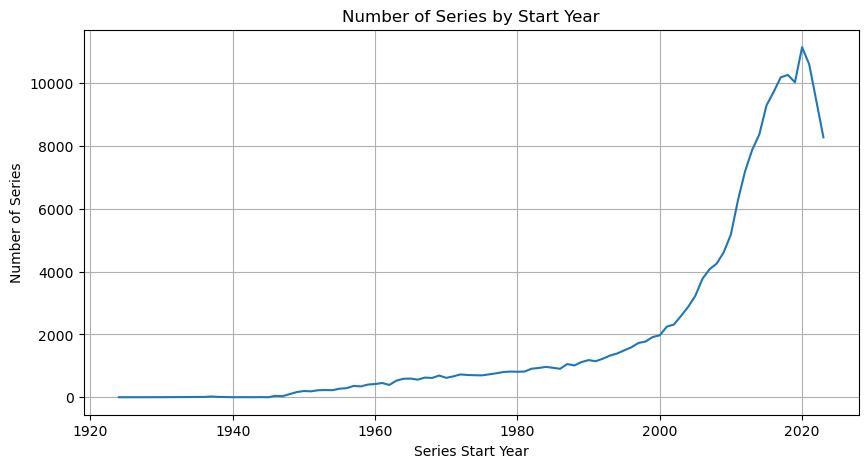

In [31]:
if "Series Start Year" in dim_Series.columns:
    series_by_year = dim_Series.dropna(subset=["Series Start Year"]).groupby("Series Start Year").size()
    
    plt.figure(figsize=(10,5))
    plt.plot(series_by_year.index, series_by_year.values)
    plt.title("Number of Series by Start Year")
    plt.xlabel("Series Start Year")
    plt.ylabel("Number of Series")
    plt.grid(True)
    plt.show()
else:
    print("Series Start Year column not found")

## Step 22 — Awards analysis

Awards can be another success signal, but we should use them together with ratings and votes.

In [32]:
print("Title award columns:")
print(fact_TitleAward.columns.tolist())

print("Series award columns:")
print(fact_SeriesAward.columns.tolist())

Title award columns:
['Is Award Winner (Title)']
Series award columns:
['Is Award Winner (Series)']


Is Award Winner (Title)
False    1980
True     1790
Name: count, dtype: int64


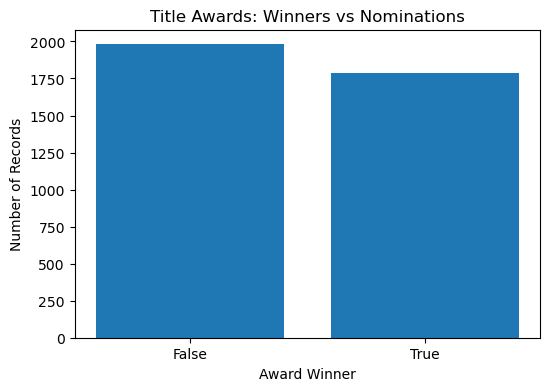

In [33]:
if "Is Award Winner (Title)" in fact_TitleAward.columns:
    title_award_counts = fact_TitleAward["Is Award Winner (Title)"].value_counts(dropna=False)
    print(title_award_counts)
    
    plt.figure(figsize=(6,4))
    plt.bar(title_award_counts.index.astype(str), title_award_counts.values)
    plt.title("Title Awards: Winners vs Nominations")
    plt.xlabel("Award Winner")
    plt.ylabel("Number of Records")
    plt.show()
else:
    print("Is Award Winner (Title) column not found")

Is Award Winner (Series)
False    122610
True      58045
Name: count, dtype: int64


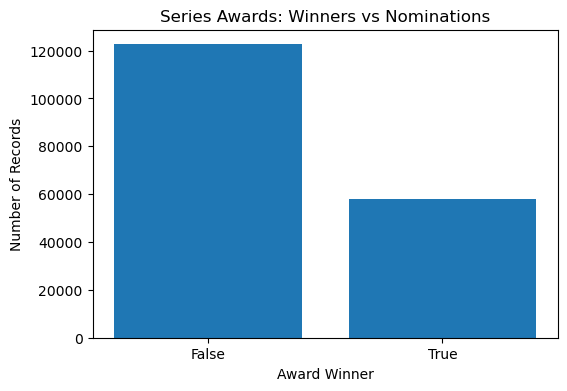

In [34]:
if "Is Award Winner (Series)" in fact_SeriesAward.columns:
    series_award_counts = fact_SeriesAward["Is Award Winner (Series)"].value_counts(dropna=False)
    print(series_award_counts)
    
    plt.figure(figsize=(6,4))
    plt.bar(series_award_counts.index.astype(str), series_award_counts.values)
    plt.title("Series Awards: Winners vs Nominations")
    plt.xlabel("Award Winner")
    plt.ylabel("Number of Records")
    plt.show()
else:
    print("Is Award Winner (Series) column not found")

## Step 23 — Genre coverage

Genre is useful for investment decisions.  
However, if the dataset does not contain proper joining keys, we cannot safely calculate genre success by title.

So here we first check which genre categories exist.

In [35]:
print("Available title genres:")
print(dim_TitleGenre.head(20))

print("Available series genres:")
print(dim_SeriesGenre.head(20))

Available title genres:
    Title Genre
0        Action
1         Adult
2     Adventure
3     Animation
4     Biography
5        Comedy
6         Crime
7   Documentary
8         Drama
9        Family
10      Fantasy
11    Game-Show
12      History
13       Horror
14        Music
15      Musical
16      Mystery
17         News
18   Reality-TV
19      Romance
Available series genres:
   Series Genre
0        Action
1         Adult
2     Adventure
3     Animation
4     Biography
5        Comedy
6         Crime
7   Documentary
8         Drama
9        Family
10      Fantasy
11    Game-Show
12      History
13       Horror
14        Music
15      Musical
16      Mystery
17         News
18   Reality-TV
19      Romance


## Step 24 — Build a simple dashboard table

This table can be exported and used in Tableau or Power BI later.

It contains only Swedish title records with important fields.

In [36]:
dashboard_data = sweden_titles.copy()

# Keep useful columns for dashboard if they exist
columns_to_keep = [
    "Title Name",
    "Release Year",
    "IMDb Title Rating",
    "IMDb Title Number Of Votes",
    "Runtime (Minutes)",
    "Country Code",
    "Season Number",
    "Episode Number"
]

available_columns = []
for col in columns_to_keep:
    if col in dashboard_data.columns:
        available_columns.append(col)

dashboard_data = dashboard_data[available_columns]

dashboard_data.head()

,Release Year,IMDb Title Rating,IMDb Title Number Of Votes,Runtime (Minutes),Country Code,Season Number,Episode Number
0,1980,6.4,5,29.0,SE,1.0,3.0
1,1980,6.4,5,30.0,SE,1.0,1.0
2,1980,6.6,5,28.0,SE,1.0,2.0
3,1980,6.6,5,28.0,SE,1.0,5.0
4,1980,6.7,6,29.0,SE,1.0,6.0


In [39]:
# Add success flag for dashboard
# First create a default value

dashboard_data["Successful Flag"] = "No"

# Calculate median votes
median_votes = dashboard_data["IMDb Title Number Of Votes"].median()

print("Median votes:", median_votes)

# Mark successful records where rating and votes meet the rule
condition = (
    (dashboard_data["IMDb Title Rating"] >= 7.0) &
    (dashboard_data["IMDb Title Number Of Votes"] >= median_votes)
)

dashboard_data.loc[condition, "Successful Flag"] = "Yes"

dashboard_data.head()

Median votes: 21.0


,Release Year,IMDb Title Rating,IMDb Title Number Of Votes,Runtime (Minutes),Country Code,Season Number,Episode Number,Successful Flag
0,1980,6.4,5,29.0,SE,1.0,3.0,No
1,1980,6.4,5,30.0,SE,1.0,1.0,No
2,1980,6.6,5,28.0,SE,1.0,2.0,No
3,1980,6.6,5,28.0,SE,1.0,5.0,No
4,1980,6.7,6,29.0,SE,1.0,6.0,No


In [40]:
# Export file for dashboard use

dashboard_data.to_csv("sweden_tv_dashboard_data.csv", index=False)

print("Dashboard data exported as sweden_tv_dashboard_data.csv")

Dashboard data exported as sweden_tv_dashboard_data.csv


# Final Business Insights

## Q1. What makes a Swedish TV series successful?

- Based on this analysis, success should be measured using both **IMDb rating** and **audience votes**.

- A Swedish TV title or series is more successful when:

  - It has an IMDb rating of 7.0 or higher
  - It has votes greater than or equal to the median vote count
  - It has clear runtime and release year information
  - It appears in a common audience age-rating category
  - It has award recognition, if available


- The average IMDb rating for Swedish TV titles is 6.91, and the median rating is 7.0, showing that many Swedish TV titles receive generally positive audience feedback.
- Using the success rule IMDb rating ≥ 7.0 and votes ≥ median votes, the analysis identified 527 successful Swedish TV titles.
- Rating alone is not enough. A title with a high rating but very few votes may not be reliable.  
For business decisions, ratings and votes should be used together.
- For business decision-making, IMDb rating and audience votes should be used together to identify titles with both audience satisfaction and audience engagement.

## Q2. What types of television shows should we invest in for the future?

The broadcaster should invest in show types that show:

  - strong IMDb ratings
  - strong audience engagement
  - runtime categories with better average rating
  - audience age-rating categories with good coverage
  - formats that show consistent performance over time

- The runtime analysis shows that medium-length titles perform best, with an average IMDb rating of approximately 7.10, compared with 6.77 for short titles and 6.68 for long titles.
- Medium-length TV content is also the most common runtime category in the Swedish title dataset, making it a strong format for future investment.
- Swedish TV title production increased strongly after 2000, with high activity around 2011–2013 and again around 2020–2023. This suggests that modern Swedish TV content is highly represented and should be tracked closely in future analyses.
- The broadcaster should avoid investing based only on very high IMDb ratings from titles with low vote counts. A title with a slightly lower rating but a stronger vote count may be a more reliable success example.

The future dashboard should track these metrics regularly when new TV data becomes available.

## Suggested dashboard KPIs

- Total Swedish TV titles
- Average IMDb rating
- Total audience votes
- Top successful titles
- Title count by release year
- Rating distribution
- Runtime category distribution
- Average rating by runtime category
- Sweden age rating distribution
- Award winners vs nominations

## Dataset limitation

- The title-level analysis is directly Sweden-focused because the fact_Title table contains Country Code == SE for all 4,829 records.
- Some supporting tables do not have direct keys to connect them clearly to Swedish titles or series.
- For example, genre, award, credit, person, and some series-related tables may not always connect directly to Country Code == SE.
- The dim_Series table contains many series records, but it does not include a country code column. Therefore, series-level results should be used as supporting analysis rather than fully Sweden-specific conclusions.
- Because of this, the analysis clearly separates the direct Sweden analysis from the supporting dataset analysis.

## Final Recommendation

- A successful Swedish TV title should be defined using a combined rule: IMDb rating ≥ 7.0 and votes ≥ median votes.
- The broadcaster should prioritize medium-length Swedish TV shows with strong audience ratings, reliable vote counts, and clear audience targeting.
- Future investment decisions should be based on a combination of rating, votes, runtime, release trend, age rating, and award recognition, rather than IMDb rating alone.
- The dashboard can be reused in the future to monitor new Swedish TV titles and help the broadcaster decide which types of shows are worth further investment.



